In [1]:
import os
import re
import csv
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

- source_file: txt file name.
- source_path: path in the original source.
- category: {INTRO, BACK}
- keywords: keywords or short phrases
- key_phrases: short phrases (not as accurate)
- snippet: piece of text with length between 250 to 1000 words
- confidence: {high, }

# Carga de Archivos

In [15]:
from google.colab import auth
from google.auth import default
from googleapiclient.discovery import build
import io
from googleapiclient.http import MediaIoBaseDownload

# 1. Authenticate your Google account
auth.authenticate_user()
creds, _ = default()

# 2. Build the Drive API client
drive_service = build('drive', 'v3', credentials=creds)
print("Successfully connected to the Google Drive API!")

Successfully connected to the Google Drive API!


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# Please update these paths with your actual file locations in Google Drive
# unified_csv = '/content/data/etiquetas_manuales/etiquetas_manuales_unificadas.csv'
unified_csv = './etiquetas_manuales_unificadas.csv'
full_contr_csv = './validacion_CONTR_edwin(2374).csv'
# text_folder_path = '/content/drive/MyDrive/core'
# text_folder_path = '/content/drive/MyDrive/MasterAI/DespliegueSoluciones/datos/copied_originals/INTRO'
# text_folder_path = 'https://drive.google.com/drive/folders/1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc?usp=drive_link'

# Autoclasificación de Segmentos

## Análisis de Frecuencias (Palabras/frases clave)

In [4]:
# 1. Cargar el dataset consolidado
# Cambia el nombre del archivo si es necesario
try:
    df = pd.read_csv(unified_csv)
    print(f"Archivo cargado exitosamente. Total de fragmentos: {len(df)}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{unified_csv}'")
    exit()

print(f"Tamaño del dataframe consolidado {df.shape}")

# 2. Función para extraer y contar los términos más frecuentes
def obtener_top_terminos(df_subset, nombre_columna, top_n=20):
    todos_los_terminos = []

    # Recorrer cada fila de la columna especificada (ej. 'keywords')
    for texto in df_subset[nombre_columna].dropna():
        # Separar por comas o puntos y comas
        terminos = re.split(r'[,;]', str(texto))
        # Limpiar espacios en blanco y convertir a minúsculas
        todos_los_terminos.extend([t.strip().lower() for t in terminos if t.strip()])

    # Contar las frecuencias y devolver los N más comunes
    return Counter(todos_los_terminos).most_common(top_n)

# 3. Analizar automáticamente todas las categorías que existan en el CSV
categorias_encontradas = df['category'].unique()
print(f"\nCategorías detectadas en el archivo: {categorias_encontradas}")

# Diccionarios para guardar los resultados
resultados_keywords = {}
resultados_frases = {}

for categoria in categorias_encontradas:
    # Filtrar el dataframe por la categoría actual
    df_categoria = df[df['category'] == categoria]

    print(f"\n{'='*40}")
    print(f"ANÁLISIS PARA LA CATEGORÍA: {categoria} (Muestras: {len(df_categoria)})")
    print(f"{'='*40}")

    # Analizar la columna 'keywords'
    top_keywords = obtener_top_terminos(df_categoria, 'keywords', top_n=15)
    print("\n--- Top 15 Keywords ---")
    for termino, frecuencia in top_keywords:
        print(f" - {termino}: {frecuencia} veces")

    # Analizar la columna 'key_phrases' (si existe en el CSV)
    if 'key_phrases' in df.columns:
        top_phrases = obtener_top_terminos(df_categoria, 'key_phrases', top_n=10)
        print("\n--- Top 10 Key Phrases ---")
        for frase, frecuencia in top_phrases:
            print(f" - {frase}: {frecuencia} veces")

Archivo cargado exitosamente. Total de fragmentos: 1601
Tamaño del dataframe consolidado (1601, 7)

Categorías detectadas en el archivo: ['CONC' 'CONTR' 'LIM' 'INTRO' 'BACK' 'DISC' 'RES' 'METH']

ANÁLISIS PARA LA CATEGORÍA: CONC (Muestras: 200)

--- Top 15 Keywords ---
 - conclusiones: 28 veces
 - trabajo futuro: 18 veces
 - estudio: 11 veces
 - investigación: 10 veces
 - trabajo: 6 veces
 - estudiante: 5 veces
 - social: 4 veces
 - calidad: 4 veces
 - información: 4 veces
 - comunicación: 4 veces
 - educación: 4 veces
 - resultados: 4 veces
 - formación: 4 veces
 - crecimiento: 4 veces
 - recomendaciones: 4 veces

--- Top 10 Key Phrases ---
 - finalmente: 3 veces
 - presente trabajo: 2 veces
 - conclusiones: 2 veces
 - una transformación cultural: 1 veces
 - productos software de calidad de acuerdo con los requisitos: 1 veces
 - la transformación digital: 1 veces
 - como: integración continua: 1 veces
 - entrega continua: 1 veces
 - tratamiento quirúrgico: 1 veces
 - turf toe: 1 veces

## Construcción de Regex y AutoEtiquetado

In [16]:
# ==========================================
# 1. CONFIGURACIÓN Y REGLAS DE AISLAMIENTO
# ==========================================

# Set to a small number (e.g., 10) for testing, then change to 2000 for the full run.
MIN_SNIPPETS_PER_CLASS = 1800
MIN_MATCHES = 2
MIN_WORDS = 250
MAX_WORDS = 1000

# Cargar los IDs que ya etiquetaste manualmente para IGNORARLOS en el autoetiquetado
# Esto asegura el cumplimiento de la regla de particionamiento estricto del documento.
df_validated = pd.read_csv(unified_csv)
manually_labeled_files = set(df_validated['source_file'].unique())

full_contr = pd.read_csv(full_contr_csv)
other_contr_files = set(full_contr['source_file'].unique()) - manually_labeled_files

# 2. Define the patterns (Spanish keywords since the text is in Spanish)
regex_patterns = {
    "INTRO": re.compile(
        r'\b(objetivo|problema\sde\sinvestigaci\w{1}n|objetivos|introducci\w{1}n|'
        r'justificaci\w{1}n|prop\w{1}sito|planteamiento\sdel\sproblema|'
        r'el\spresente\strabajo\s(aborda|tiene\scomo|se\scentra)|'
        r'esta\sinvestigaci\w{1}n|la\sfinalidad\sde)\b',
        re.IGNORECASE
    ),
    "BACK": re.compile(
        r'\b(antecedentes|estado\sdel\sarte|trabajos\sprevios|'
        r'marco\ste\w{1}rico|estudios\sprevios|investigaciones\sprevias|'
        r'revisi\w{1}n\sbibliogr\w{1}fica|literatura\scient\w{1}fica|'
        r'trabajo\srelacionado|et\sal\.|seg\w{1}n\s[A-Z][a-z]+|'
        r'estudios\santeriores|tradicionalmente)\b',
        re.IGNORECASE
    ),
    "METH": re.compile(
        r'\b('
        r'metodolog[íi]a|metodolog[íi]as|metodol[oó]gico|metodol[oó]gica|'
        r'cuestionario|cuestionarios|'
        r'muestreo|muestra|muestras|'
        r'encuesta|encuestas|'
        r'instrumento|instrumentos|'
        r'procedimiento|procedimientos|'
        r'participantes|'
        r'entrevista|entrevistas|'
        r'm[eé]todo|m[eé]todos|'
        r'materiales\sy\sm[eé]todos|material\sy\sm[eé]todo|materiales\sy\st[eé]cnicas|'
        r'dise[ñn]o\s(?:no\s)?experimental|dise[ñn]o\smetodol[oó]gico|'
        r'dise[ñn]o\sde\s(?:la\s)?investigaci[oó]n|'
        r'no\sexperimental|transversal|observacional|'
        r'enfoque\scuantitativo|enfoque\scualitativo|enfoque\smetodol[oó]gico|'
        r'investigaci[oó]n\scualitativa|investigaci[oó]n\scuantitativa|'
        r'tipo\sde\sinvestigaci[oó]n|tipo\sde\sestudio|'
        r'tipo\sy\sdise[ñn]o\sde\sinvestigaci[oó]n|'
        r'paradigma\scualitativo|paradigma\scuantitativo|'
        r'an[aá]lisis\sde\sdatos|m[eé]todo\sde\san[aá]lisis|'
        r'an[aá]lisis\sestad[íi]stico|an[aá]lisis\sdescriptivo|'
        r'an[aá]lisis\sde\scontenido|an[aá]lisis\sdocumental|'
        r'revisi[oó]n\ssistem[aá]tica|'
        r'm[eé]todo\sdeductivo|m[eé]todo\sinductivo|m[eé]todo\scient[íi]fico|'
        r't[eé]cnicas\smetodol[oó]gicas'
        r')\b',
        re.IGNORECASE
    ),
    "RES": re.compile(
        r'\b('
        # Marcadores de sección y frases de apertura
        r'resultados|hallazgos|los\sresultados\smuestran|los\sresultados\sindican|'
        r'los\sresultados\sobtenidos|los\sdatos\smuestran|los\sanálisis\smuestran|'
        r'el\sanálisis\sindica|el\sanálisis\sreveló|'

        # Verbos de hallazgo en pasado (núcleo del reporte empírico)
        r'se\sencontró\sque|se\sobservó\sque|se\sidentificó|se\sdetectó|'
        r'se\sevidenció|se\sregistró|se\sobtuvieron|se\spudo\sobservar|'
        r'se\sapreció|arrojó|reveló|mostró|evidenció|'

        # Referencias a elementos visuales/tabulares
        r'como\sse\smuestra\sen|como\sse\sobserva\sen|como\sse\saprecia\sen|'
        r'en\sla\sfigura|en\sel\sgráfico|en\sla\stabla|en\sel\scuadro|'
        r'tal\scomo\sse\smuestra|véase\sla\sfigura|véase\sla\stabla|'

        # Lenguaje estadístico cuantitativo
        r'estadísticamente\ssignificativo|diferencia\ssignificativa|'
        r'no\ssignificativo|correlación\spositiva|correlación\snegativa|'
        r'valor\sde\sp|p\s[<>≤≥]\s0\.|intervalo\sde\sconfianza|'
        r'desviación\sestándar|error\sestándar|media\sde|mediana\sde|'
        r'coeficiente\sde|odds\sratio|razón\sde|frecuencia\srelativa|'

        # Cuantificaciones comparativas
        r'un\saumento\sde|una\sreducción\sde|una\sdisminución\sde|'
        r'superior\sa|inferior\sa|mayor\sque|menor\sque|'
        r'el\s\d+\s?%\sde|un\s\d+\s?%|aproximadamente\sel|'
        r'los\sresultados\sobtuvieron|los\sparticipantes\sreportaron'
        r')\b',
        re.IGNORECASE
    ),
    "DISC": re.compile(
        r'\b(discusión|estos\sresultados\ssugieren|a\sla\sluz\sde|esto\simplica|'
        r'esto\sindica\sque|esto\sse\sdebe\sa|en\snuestra\sopinión|en\smi\sopinión|'
        r'lo\sque\ssignifica\sque|lo\scual\sindica|lo\sque\simplica|'
        r'a\sla\shora\sde\sdiscutir|estos\shallazgos|interpretación|reflexión|'
        r'lleva\sa\spensar|nos\slleva\sa\sconcluir|en\scontraste\scon|'
        r'coincide\scon|difiere\sde|corrobora|contrario\sa\slo\sesperado)\b',
        re.IGNORECASE
    ),
    # "CONTR": re.compile(r'\b(contribución|este\strabajo\saporta|nuestro\senfoque|se\spropone\sun\snuevo)\b', re.IGNORECASE),
    "LIM": re.compile(
        r'\b(limitación|limitaciones|no\sfue\sposible|no\ses\sposible|'
        r'no\sse\spuede|sesgo|sesgado|sesgada|se\sdesconoce|imposibilidad|'
        r'no\spermite|fuera\sdel\salcance|no\sse\spudo|no\sse\spretende|'
        r'restricción|no\sgeneraliz|no\srepresenta|tamaño\sde\sla\smuestra|'
        r'tamaño\smuestral|muestra\spequeña|futuras\sinvestigaciones|'
        r'futuras\slíneas|líneas\sfuturas|investigación\sfutura|'
        r'trabajo\sfuturo|queda\spendiente|falta\sde|carencia\sde|'
        r'no\sse\sdispone|pese\sa\sno\scontar|sin\scontar\scon|'
        r'no\sabarca|no\sincluye|no\scontempla|ciertas\slimitaciones|'
        r'estas\slimitaciones|dificulta|dificultades\sy\slimitaciones|'
        r'diseño\stransversal\sno\spermite)\b',
        re.IGNORECASE
    ),
    "CONC": re.compile(
        r'\b('
        # Marcadores de sección explícitos
        r'conclusiones|conclusión|en\sconclusión|a\smodo\sde\sconclusión|'
        r'para\sconcluir|como\sconclusión|a\stítulo\sde\sconclusión|'

        # Verbos y frases de cierre epistémico
        r'se\sconcluye\sque|podemos\sconcluir|cabe\sconcluir|'
        r'es\sposible\sconcluir|permite\sconcluir|lleva\sa\sconcluir|'
        r'los\sresultados\spermiten\sconcluir|los\shallazgos\spermiten\sconcluir|'

        # Síntesis y resumen (más fuerte que un simple "en resumen")
        r'en\sresumen|en\ssíntesis|en\sdefinitiva|en\súltima\sinstancia|'
        r'en\sconjunto[,\s]|tomados\sen\sconjunto|globalmente[,\s]|'
        r'en\sglobal|en\stérminos\sgenerales[,\s]|'

        # Afirmaciones de cierre sobre el estudio
        r'este\sestudio\sha\sdemostrado|este\strabajo\sha\sdemostrado|'
        r'esta\sinvestigación\sha\sconfirmado|este\sestudio\sconfirma|'
        r'este\strabajo\saporta\sevidencia|se\sha\sdemostrado\sque|'
        r'se\sha\scomprobado\sque|se\sha\sevidenciado\sque|'
        r'los\sresultados\sobtenidos\sconfirman|'

        # Prospectiva (recomendaciones y trabajo futuro — complementa a LIM)
        r'se\srecomienda|se\ssugiere\sque|futuras\sinvestigaciones\sdebería|'
        r'próximas\sinvestigaciones|estudios\sfuturos\sdebería|'
        r'es\snecesario\sfollowing|queda\spendiente\spara\sfuturas|'
        r'finalmente[,\s]'
        r')\b',
        re.IGNORECASE
    ),
}

# ==========================================
# 3. FUNCIONES CORE
# ==========================================

def segment_text(text, min_words=250, max_words=1000):
    """
    Divides the text into length-controlled snippets,
    accumulating paragraphs to maintain semantic coherence.
    """
    paragraphs = text.split('\n')
    snippets = []
    current_snippet = []
    words_count = 0

    for p in paragraphs:
        paragraph_words = p.split()
        p_words = len(paragraph_words)

        if p_words == 0:
            continue

        # If adding the paragraph keeps the snippet within the max limit
        if words_count + p_words <= max_words:
            current_snippet.append(p)
            words_count += p_words
        else:
            # If it exceeds the max, save what we have if it meets the minimum
            if words_count >= min_words:
                snippets.append(" ".join(current_snippet).strip())

            # Start a new snippet
            # If the current paragraph ALONE exceeds max_words (e.g., bad PDF extraction),
            # we truncate it so we don't lose the data or break the project rules.
            if p_words > max_words:
                truncated_p = " ".join(paragraph_words[:max_words])
                snippets.append(truncated_p)
                current_snippet = []
                words_count = 0
            else:
                current_snippet = [p]
                words_count = p_words

    # Validate the remainder at the end of the loop
    if min_words <= words_count <= max_words:
        snippets.append(" ".join(current_snippet).strip())

    return snippets


def classify_snippet_detailed(snippet, regex_patterns, threshold=MIN_MATCHES):
    """
    Returns the category, the score, and the exact words that matched.
    """
    scores = {}
    matches_dict = {}

    for category, pattern in regex_patterns.items():
        matches = pattern.findall(snippet)

        if len(matches) > 0:
            scores[category] = len(matches)
            # Handle both strings and tuples returned by regex findall
            clean_words = [m.lower() if isinstance(m, str) else m[0].lower() for m in matches]
            matches_dict[category] = list(set(clean_words)) # Remove duplicates

    if scores:
        best_category = max(scores, key=scores.get)
        if scores[best_category] >= threshold:
            return best_category, scores[best_category], matches_dict[best_category]

    return None, 0, []


In [33]:
# # ==========================================
# BUSCA EL DRIVE PERO FALLA
# ==========================================
'''
def auto_label_directory(input_dir, output_csv, manually_labeled_files, regex_patterns):
    """
    Reads the txt files, extracts the best snippet per category,
    and prevents duplicates or overlapping with manually validated data.
    """
    results = []

    # Tracker for early stopping
    category_counts = {cat: 0 for cat in regex_patterns.keys()}
    files_processed = 0

    print(f"Scanning directory using iterators to prevent memory overflow...")

    try:
        # Use os.scandir instead of os.listdir
        # 'with' ensures the directory iterator is properly closed afterward
        with os.scandir(input_dir) as entries:
            # for filename in os.listdir(input_dir):  # TODO: Break the loop when there are no more filenames left, or every category has 2000 snippets from different files.
            for entry in entries:
                if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):
                    print(f"\n[SUCCESS] Early stopping triggered! All categories have at least {MIN_SNIPPETS_PER_CLASS} snippets.")
                    break

                # Skip non-txt files or files already manually labeled
                # if not filename.endswith('.txt') or filename in manually_labeled_files:
                #    continue

                # 2. Skip if it's a folder, not a .txt, or already manually labeled
                if not entry.is_file() or not entry.name.endswith('.txt') or entry.name in manually_labeled_files:
                    continue

                filepath = entry.path
                filename = entry.name

                # filepath = os.path.join(input_dir, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        text = f.read()

                    snippets = segment_text(text, min_words=MIN_WORDS, max_words=MAX_WORDS)

                    # Dictionary to store the BEST snippet of each category for THIS specific file
                    best_snippets_per_file = {}

                    for snippet in snippets:
                        category, score, found_keywords = classify_snippet_detailed(snippet, regex_patterns, threshold=2)

                        if category:
                            # If the category is new for this file, or if this snippet has a higher score
                            if category not in best_snippets_per_file or score > best_snippets_per_file[category]['regex_score']:
                                best_snippets_per_file[category] = {
                                    'source_file': filename,
                                    'category': category,
                                    'snippet': snippet,
                                    'word_count': len(snippet.split()),
                                    'matched_keywords': ", ".join(found_keywords),
                                    'regex_score': score
                                }

                    # Add the values from the dictionary to the flat results list
                    for cat, data in best_snippets_per_file.items():
                        results.append(data)
                        category_counts[cat] += 1

                    files_processed += 1

                    if files_processed % 1000 == 0:
                        print(f"Processed {files_processed} files. Current counts: {category_counts}")

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

    except OSError as e:
        print(f"\nCRITICAL I/O ERROR: Google Drive timed out while scanning. Error: {e}")
        print("Saving whatever progress we made so far...")

    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(output_csv, index=False, encoding='utf-8')

        print("\n--- FINAL CATEGORY DISTRIBUTION ---")
        print(df_results['category'].value_counts())
        print(f"Done! Successfully generated {len(df_results)} auto-labeled snippets from {df_results.source_file.nunique()} files.")
        return df_results
    else:
        print("No snippets were generated.")
        return pd.DataFrame()


# EJEMPLO DE USO:
auto_labeled_df = auto_label_directory(text_folder_path, 'auto_labeled_output.csv', manually_labeled_files, regex_patterns)
auto_labeled_df
'''

'\ndef auto_label_directory(input_dir, output_csv, manually_labeled_files, regex_patterns):\n    """\n    Reads the txt files, extracts the best snippet per category,\n    and prevents duplicates or overlapping with manually validated data.\n    """\n    results = []\n\n    # Tracker for early stopping\n    category_counts = {cat: 0 for cat in regex_patterns.keys()}\n    files_processed = 0\n\n    print(f"Scanning directory using iterators to prevent memory overflow...")\n\n    try:\n        # Use os.scandir instead of os.listdir\n        # \'with\' ensures the directory iterator is properly closed afterward\n        with os.scandir(input_dir) as entries:\n            # for filename in os.listdir(input_dir):  # TODO: Break the loop when there are no more filenames left, or every category has 2000 snippets from different files.\n            for entry in entries:\n                if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):\n                    print(f"\

In [17]:


# ==========================================
# DIRECTORY EXECUTION (VIA GOOGLE DRIVE API)
# ==========================================

def download_file_content(drive_service, file_id):
    """Downloads a text file directly into memory from Google Drive."""
    request = drive_service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while done is False:
        status, done = downloader.next_chunk()
    return fh.getvalue().decode('utf-8')


def auto_label_drive_api(folder_id, output_csv, manually_labeled_files, regex_patterns):
    """
    Reads files from a massive shared Google Drive folder using the Drive API
    to completely bypass Colab's FUSE timeout errors.
    """
    results = []
    category_counts = {cat: 0 for cat in regex_patterns.keys()}
    files_processed = 0

    print("Querying Google Drive API...")

    page_token = None
    early_stop = False

    try:
        while not early_stop:
            try:
                # Query the API: "Give me up to 1000 .txt files inside this specific folder"
                # We use name contains '.txt' to filter quickly on Google's servers
                response = drive_service.files().list(
                    q=f"'{folder_id}' in parents and name contains '.txt' and trashed = false",
                    spaces='drive',
                    fields='nextPageToken, files(id, name)',
                    pageSize=1000,
                    pageToken=page_token
                ).execute()

                files = response.get('files', [])

                if not files:
                    print("No more files found in the folder.")
                    break

                for file_item in files:
                    # 1. Check Early Stopping Condition
                    if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):
                        print(f"\n[SUCCESS] Early stopping triggered! All categories have at least {MIN_SNIPPETS_PER_CLASS} snippets.")
                        early_stop = True
                        break

                    filename = file_item.get('name')
                    file_id = file_item.get('id')

                    # 2. Skip if manually labeled
                    if filename in manually_labeled_files:
                        continue

                    try:
                        # 3. Download the text directly into memory
                        text = download_file_content(drive_service, file_id)

                        # 4. Run your exact NLP pipeline
                        snippets = segment_text(text, min_words=MIN_WORDS, max_words=MAX_WORDS)
                        best_snippets_per_file = {}

                        for snippet in snippets:
                            category, score, found_keywords = classify_snippet_detailed(snippet, regex_patterns, threshold=MIN_MATCHES)

                            if category:
                                if category not in best_snippets_per_file or score > best_snippets_per_file[category]['regex_score']:
                                    best_snippets_per_file[category] = {
                                        'source_file': filename,
                                        'category': category,
                                        'snippet': snippet,
                                        'word_count': len(snippet.split()),
                                        'matched_keywords': ", ".join(found_keywords),
                                        'regex_score': score
                                    }

                        # 5. Add to results and update the tracker
                        for cat, data in best_snippets_per_file.items():
                            results.append(data)
                            category_counts[cat] += 1

                        files_processed += 1

                        if files_processed % 50 == 0:
                            print(f"Processed {files_processed} files... Current counts: {category_counts}")

                    except Exception as e:
                        print(f"Error processing {filename}: {e}")

                # Get the token for the next 1000 files
                page_token = response.get('nextPageToken', None)
                if page_token is None:
                    break # We reached the end of the folder

            except Exception as e:
                print(f"API Error occurred: {e}")
                break

    except KeyboardInterrupt:
        print("\n\n[!] Execution interrupted manually by the user.")
        print("[!] Stopping safely and preparing to save collected data...")

    # Save results
    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(output_csv, index=False, encoding='utf-8')

        print("\n--- FINAL CATEGORY DISTRIBUTION ---")
        print(df_results['category'].value_counts())
        print(f"Done! Generated {len(df_results)} snippets from {df_results.source_file.nunique()} files.")
        return df_results
    else:
        print("No snippets were generated.")
        return pd.DataFrame()

# ==========================================
# EXECUTION
# ==========================================
# The ID is extracted from your partner's URL: https://drive.google.com/drive/folders/1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc
SHARED_FOLDER_ID = '1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc'

auto_labeled_df = auto_label_drive_api(
    folder_id=SHARED_FOLDER_ID,
    output_csv='auto_labeled_output.csv',
    manually_labeled_files=(manually_labeled_files | other_contr_files),
    regex_patterns=regex_patterns
)

Querying Google Drive API...


Processed 50 files... Current counts: {'INTRO': 11, 'BACK': 7, 'METH': 21, 'RES': 5, 'DISC': 1, 'LIM': 3, 'CONC': 3}
Processed 100 files... Current counts: {'INTRO': 31, 'BACK': 13, 'METH': 42, 'RES': 10, 'DISC': 3, 'LIM': 5, 'CONC': 5}
Processed 150 files... Current counts: {'INTRO': 48, 'BACK': 21, 'METH': 64, 'RES': 18, 'DISC': 6, 'LIM': 8, 'CONC': 9}
Processed 200 files... Current counts: {'INTRO': 63, 'BACK': 28, 'METH': 87, 'RES': 24, 'DISC': 9, 'LIM': 12, 'CONC': 11}
Processed 250 files... Current counts: {'INTRO': 82, 'BACK': 34, 'METH': 108, 'RES': 35, 'DISC': 12, 'LIM': 15, 'CONC': 12}
Processed 300 files... Current counts: {'INTRO': 99, 'BACK': 38, 'METH': 135, 'RES': 44, 'DISC': 15, 'LIM': 19, 'CONC': 16}
Processed 350 files... Current counts: {'INTRO': 118, 'BACK': 43, 'METH': 152, 'RES': 52, 'DISC': 19, 'LIM': 20, 'CONC': 17}
Processed 400 files... Current counts: {'INTRO': 136, 'BACK': 51, 'METH': 176, 'RES': 60, 'DISC': 20, 'LIM': 25, 'CONC': 20}
Processed 450 files... 

Processed 1150 files... Current counts: {'INTRO': 392, 'BACK': 150, 'METH': 499, 'RES': 193, 'DISC': 64, 'LIM': 75, 'CONC': 63}
Processed 1200 files... Current counts: {'INTRO': 404, 'BACK': 158, 'METH': 525, 'RES': 199, 'DISC': 70, 'LIM': 77, 'CONC': 66}
Processed 1250 files... Current counts: {'INTRO': 427, 'BACK': 166, 'METH': 549, 'RES': 205, 'DISC': 74, 'LIM': 81, 'CONC': 69}
Processed 1300 files... Current counts: {'INTRO': 441, 'BACK': 174, 'METH': 575, 'RES': 215, 'DISC': 77, 'LIM': 84, 'CONC': 71}
Processed 1350 files... Current counts: {'INTRO': 456, 'BACK': 180, 'METH': 596, 'RES': 221, 'DISC': 80, 'LIM': 85, 'CONC': 74}
Processed 1400 files... Current counts: {'INTRO': 476, 'BACK': 185, 'METH': 608, 'RES': 228, 'DISC': 85, 'LIM': 88, 'CONC': 77}
Processed 1450 files... Current counts: {'INTRO': 491, 'BACK': 192, 'METH': 627, 'RES': 235, 'DISC': 87, 'LIM': 90, 'CONC': 80}
Processed 1500 files... Current counts: {'INTRO': 509, 'BACK': 199, 'METH': 647, 'RES': 244, 'DISC': 90,

# Análisis Exploratorio de Datos


--- EDA REPORT ---
Successfully loaded dataset: 19 total snippets.

1. CLASS DISTRIBUTION
------------------------------
category
METH     10
INTRO     3
BACK      2
RES       1
DISC      1
LIM       1
CONC      1
Name: count, dtype: int64




/tmp/ipykernel_6787/2055748075.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')


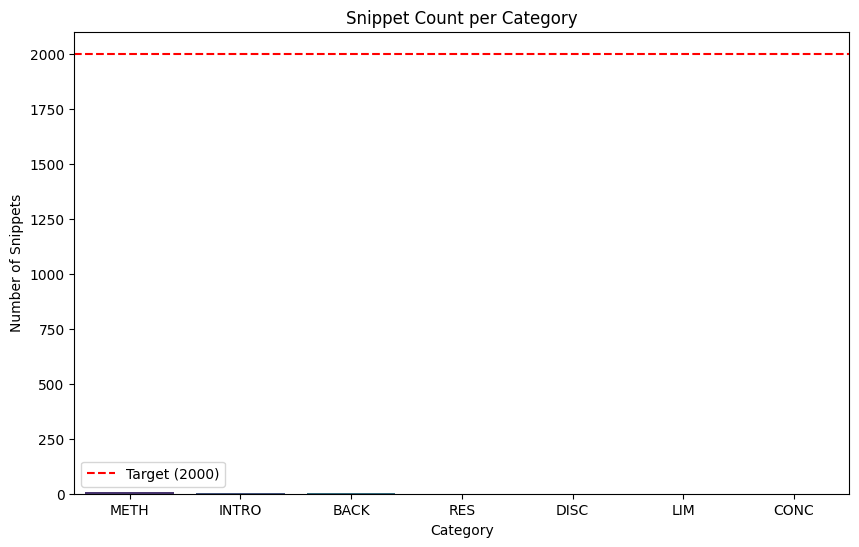


2. WORD COUNT CONSTRAINTS
------------------------------
count      19.000000
mean      943.684211
std       161.693830
min       331.000000
25%       988.500000
50%       995.000000
75%      1000.000000
max      1000.000000
Name: word_count, dtype: float64

SUCCESS: All snippets are strictly within the 250 - 1000 word limit.


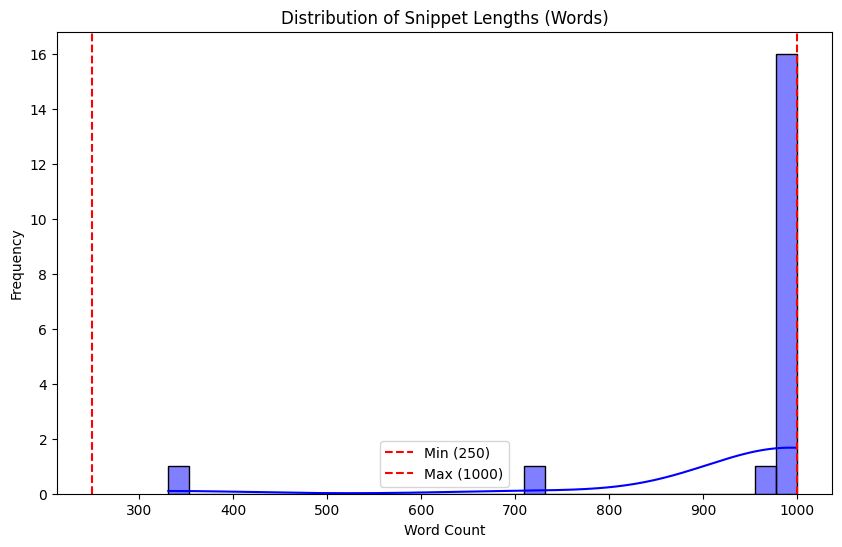


3. REGEX SCORE (CONFIDENCE)
------------------------------
category
BACK     29.0
CONC      2.0
DISC      3.0
INTRO     7.0
LIM       4.0
METH      6.2
RES      26.0
Name: regex_score, dtype: float64

4. WORD COUNT BY CATEGORY (Length Bias Check)
------------------------------


/tmp/ipykernel_6787/2055748075.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='Set2')


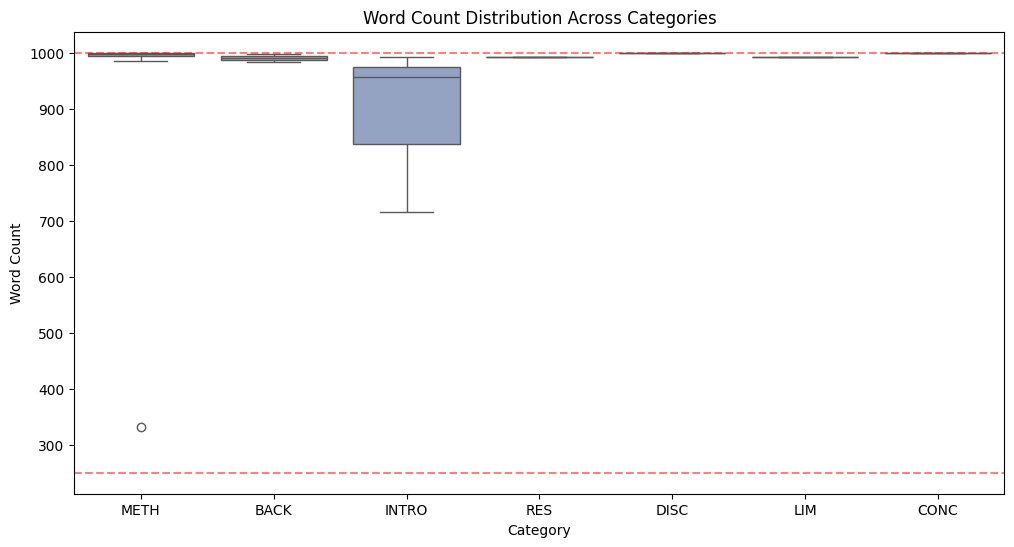


5. KEYWORD DIVERSITY
------------------------------

Top 5 triggers for METH:
  - 'muestra': 5 times
  - 'método': 3 times
  - 'metodológico': 2 times
  - 'metodología': 2 times
  - 'instrumentos': 2 times

Top 5 triggers for BACK:
  - 'según lo': 1 times
  - 'según esta': 1 times
  - 'según los': 1 times
  - 'antecedentes': 1 times

Top 5 triggers for INTRO:
  - 'propósito': 2 times
  - 'objetivo': 2 times
  - 'objetivos': 2 times
  - 'introducción': 1 times

Top 5 triggers for RES:
  - 'mediana de': 1 times
  - 'coeficiente de': 1 times
  - 'desviación estándar': 1 times
  - 'resultados': 1 times

Top 5 triggers for DISC:
  - 'discusión': 1 times

Top 5 triggers for LIM:
  - 'falta de': 1 times

Top 5 triggers for CONC:
  - 'conclusión': 1 times

6. DATA INTEGRITY CHECKS
------------------------------
Null/Empty snippets: 0
Exact duplicate snippets: 0
Files contributing to more than one category: 3 (Should ideally be low/zero for strict separation)

7. QUICK AUDIT (Top 2 highest sco

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_eda(input_csv):
    """
    Performs Exploratory Data Analysis on the auto-labeled dataset
    to ensure it meets the project constraints before training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"--- EDA REPORT ---")
        print(f"Successfully loaded dataset: {len(df)} total snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # CLASS BALANCE ANALYSIS
    print("1. CLASS DISTRIBUTION")
    print("-" * 30)
    class_counts = df['category'].value_counts()
    print(class_counts)
    print("\n")

    # Plot Class Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')
    plt.title('Snippet Count per Category')
    plt.ylabel('Number of Snippets')
    plt.xlabel('Category')
    plt.axhline(y=2000, color='r', linestyle='--', label='Target (2000)')
    plt.legend()
    # plt.savefig('eda_class_distribution.png')
    # plt.close()
    # print("-> Saved class distribution plot as 'eda_class_distribution.png'")
    plt.show()

    # WORD COUNT CONSTRAINTS (Crucial for your project)
    print("\n2. WORD COUNT CONSTRAINTS")
    print("-" * 30)
    print(df['word_count'].describe())

    # Check for violations (below 250 or above 1000)
    violations = df[(df['word_count'] < 250) | (df['word_count'] > 1000)]
    if not violations.empty:
        print(f"\nWARNING: Found {len(violations)} snippets that violate the 250-1000 word limit!")
        print("Please check these source files:")
        print(violations[['source_file', 'category', 'word_count']].head())
    else:
        print("\nSUCCESS: All snippets are strictly within the 250 - 1000 word limit.")

    # Plot Word Count Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='word_count', bins=30, kde=True, color='blue')
    plt.title('Distribution of Snippet Lengths (Words)')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.axvline(x=250, color='r', linestyle='--', label='Min (250)')
    plt.axvline(x=1000, color='r', linestyle='--', label='Max (1000)')
    plt.legend()
    # plt.savefig('eda_word_count.png')
    # plt.close()
    # print("-> Saved word count distribution plot as 'eda_word_count.png'")
    plt.show()

    # REGEX CONFIDENCE (Are we matching enough words?)
    print("\n3. REGEX SCORE (CONFIDENCE)")
    print("-" * 30)
    avg_score_per_class = df.groupby('category')['regex_score'].mean().round(2)
    print(avg_score_per_class)

    # WORD COUNT BY CATEGORY (Checking for Length Bias)
    print("\n4. WORD COUNT BY CATEGORY (Length Bias Check)")
    print("-" * 30)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='category', y='word_count', palette='Set2')
    plt.title('Word Count Distribution Across Categories')
    plt.ylabel('Word Count')
    plt.xlabel('Category')
    plt.axhline(y=250, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=1000, color='r', linestyle='--', alpha=0.5)
    plt.show()

    # KEYWORD DIVERSITY (What is triggering the regex?)
    print("\n5. KEYWORD DIVERSITY")
    print("-" * 30)
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        all_kws = []
        for kw_string in cat_df['matched_keywords'].dropna():
            # Split by comma and clean
            kws = [k.strip() for k in kw_string.split(',') if k.strip()]
            all_kws.extend(kws)

        top_kws = Counter(all_kws).most_common(5)
        print(f"\nTop 5 triggers for {category}:")
        for kw, count in top_kws:
            print(f"  - '{kw}': {count} times")

    # DATA INTEGRITY (Duplicates & Nulls)
    print("\n6. DATA INTEGRITY CHECKS")
    print("-" * 30)

    # Check for empty snippets
    null_snippets = df['snippet'].isnull().sum()
    print(f"Null/Empty snippets: {null_snippets}")

    # Check for exact duplicate snippets (could happen if a PDF was read twice)
    duplicate_snippets = df.duplicated(subset=['snippet']).sum()
    print(f"Exact duplicate snippets: {duplicate_snippets}")
    if duplicate_snippets > 0:
        print("  -> Consider dropping duplicates: df.drop_duplicates(subset=['snippet'])")

    # Check for files that accidentally got assigned multiple categories
    # (Our script prevents this, but good to double check)
    files_with_multiple_cats = df.groupby('source_file')['category'].nunique()
    multi_cat_files = files_with_multiple_cats[files_with_multiple_cats > 1].count()
    print(f"Files contributing to more than one category: {multi_cat_files} (Should ideally be low/zero for strict separation)")

    # QUICK AUDIT
    print("\n7. QUICK AUDIT (Top 2 highest scoring snippets)")
    print("-" * 30)
    top_snippets = df.sort_values(by='regex_score', ascending=False).head(2)
    for index, row in top_snippets.iterrows():
        print(f"File: {row['source_file']} | Category: {row['category']}")
        print(f"Keywords Matched: {row['matched_keywords']}")
        print(f"Score: {row['regex_score']}\n")

# ==========================================
# EXECUTION
# ==========================================
# Run this on your output from the auto-labeler
run_eda('auto_labeled_output.csv')

# Entrenamiento

## Neutralization Snippets

In [ ]:
def neutralize_snippets(input_csv, output_csv, mask_token="[MASK]"):
    """
    Reads the auto-labeled dataset, finds the matched keywords in the snippet,
    and replaces them with a neutral token to prevent data leakage during training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"Loaded dataset with {len(df)} rows.")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # Ensure the required columns exist
    if 'snippet' not in df.columns or 'matched_keywords' not in df.columns:
        print("Error: The CSV must contain 'snippet' and 'matched_keywords' columns.")
        return

    neutralized_snippets = []

    for index, row in df.iterrows():
        original_text = str(row['snippet'])
        keywords_str = str(row['matched_keywords'])

        # If there are no keywords to replace, keep the original text
        if pd.isna(row['matched_keywords']) or not keywords_str.strip():
            neutralized_snippets.append(original_text)
            continue

        # Extract keywords and clean them
        keywords = [k.strip() for k in keywords_str.split(',') if k.strip()]

        # CRITICAL: Sort keywords by length descending!
        # This prevents partial replacements (e.g., replacing "problema" before "problema de investigación")
        keywords.sort(key=len, reverse=True)

        neutralized_text = original_text

        for kw in keywords:
            # Escape regex characters just in case (e.g., if a keyword has a period like "et al.")
            escaped_kw = re.escape(kw)
            # Use word boundaries (\b) so we don't accidentally replace parts of other words
            # Ignore case so it matches "Objetivo" or "OBJETIVO"
            pattern = re.compile(rf'\b{escaped_kw}\b', re.IGNORECASE)
            neutralized_text = pattern.sub(mask_token, neutralized_text)

        neutralized_snippets.append(neutralized_text)

    # Add the new column to the dataframe
    df['neutralized_snippet'] = neutralized_snippets

    # Save the prepared dataset
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"Success! Neutralized dataset saved to {output_csv}")

    # Print a quick sample so you can verify it worked
    print("\n--- Quick Verification Sample ---")
    sample = df[df['matched_keywords'].notna()].head(1)
    if not sample.empty:
        print(f"ORIGINAL: {sample['snippet'].values[0][:150]}...")
        print(f"KEYWORDS: {sample['matched_keywords'].values[0]}")
        print(f"NEUTRALIZED: {sample['neutralized_snippet'].values[0][:150]}...")

    return df
# ==========================================
# EXECUTION
# ==========================================
# Run this AFTER you have generated your auto-labeled CSV from Step 1
neutralized_snippets = neutralize_snippets('auto_labeled_output.csv', 'neutralized_dataset.csv')


Loaded dataset with 192 rows.
Success! Neutralized dataset saved to training_ready_dataset.csv

--- Quick Verification Sample ---
ORIGINAL: gestando desde fines de la primera década del siglo xx cf. Gayon, 1992, p. 313. Pero el tono general, el modo de argumentación de esa obra, definido p...
KEYWORDS: según las, según este
NEUTRALIZED: gestando desde fines de la primera década del siglo xx cf. Gayon, 1992, p. 313. Pero el tono general, el modo de argumentación de esa obra, definido p...


In [ ]:
neutralized_snippets

,source_file,category,snippet,word_count,matched_keywords,regex_score,neutralized_snippet
0,74854421.txt,BACK,gestando desde fines de la primera década del ...,990,"según las, según este",2,gestando desde fines de la primera década del ...
1,74854421.txt,RES,morfológicos y etológicos de hormigas que enco...,980,resultados,4,morfológicos y etológicos de hormigas que enco...
2,74854421.txt,CONTR,"recimiento de la síntesis, a mí me parece mejo...",999,contribución,3,"recimiento de la síntesis, a mí me parece mejo..."
3,74854421.txt,INTRO,"p. 198 ss.. Pero, si hay algo que refleja clar...",1000,"objetivo, propósito",2,"p. 198 ss.. Pero, si hay algo que refleja clar..."
4,17915812.txt,INTRO,98 AGROPRODUCTIVIDADAgroproductividad: Vol. 11...,1000,objetivo,2,98 AGROPRODUCTIVIDADAgroproductividad: Vol. 11...
...,...,...,...,...,...,...,...
187,151593366.txt,INTRO,Universidad Nacional Mayor de San Marcos Unive...,1000,"objetivo, justificación, planteamiento del pro...",9,Universidad Nacional Mayor de San Marcos Unive...
188,268519324.txt,INTRO,I UNIVERSIDAD NACIONAL DE CHIMBORAZO FACULTAD ...,1000,"introducción, objetivos, objetivo, justificaci...",6,I UNIVERSIDAD NACIONAL DE CHIMBORAZO FACULTAD ...
189,163224667.txt,INTRO,UNIVERSIDAD TÉCNICA DE BABAHOYO FACULTAD DE AD...,1000,"introducción, objetivos, objetivo",5,UNIVERSIDAD TÉCNICA DE BABAHOYO FACULTAD DE AD...
190,168348001.txt,INTRO,TRABAJO FIN DE ESTUDIOSTítuloProyecto de Apren...,1000,"introducción, objetivos, objetivo",6,TRABAJO FIN DE ESTUDIOSTítuloProyecto de Apren...


In [ ]:
neutralized_snippets.loc[3, ["neutralized_snippet"]].values

array(['p. 198 ss.. Pero, si hay algo que refleja claramente el adaptacionismo agresivo, y hasta petulante, que se había instalado entre muchos evolucionistas de ese momento, ese es, sin duda, el artículo publicado por el fordista Arthur Cain 1989 1964. Dicho artículo parte de un presupuesto que es casi un eco de Wallace: si noso- tros, personalmente, no podemos ver cualquier significado adaptativo o funcional en un rasgo, eso se debe más a nuestra ignorancia abismal que al hecho de que ese rasgo sea realmente no-adaptativo, selectivamente neutral o carente de función Cain, 1989 756 Gustavo Caponi scienti zudia, So Paulo, v. 9, n. 4, p. 739-75, 2011 1964, p. 4.18 Pero, además de eso, Cain 1989 1964, p. 11 también critica los re- paros del propio Darwin cf. 1859, p. 434 sobre la pertinencia de explicar en términos utilitarios la presencia en una forma actual de rasgos heredados de su forma ancestral cf. Shanahan, 2004, p. 137. Para Cain 1989 1964, p. 12, esos reparos de Darwin eran un r

## Train / Validation / Test Split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

def create_strict_partitions(manual_csv, auto_neutralized_csv, val_size=0.15):
    """
    Creates Train, Validation, and Test datasets ensuring NO document-level overlap.
    """
    print("--- 1. LOADING DATA ---")
    # Load the manually validated data (The Golden Test Set)
    test_df = pd.read_csv(manual_csv)
    print(f"Test Set (Manual): {len(test_df)} snippets loaded.")

    # Load the neutralized auto-labeled data
    auto_df = pd.read_csv(auto_neutralized_csv)
    print(f"Auto-labeled Set: {len(auto_df)} snippets loaded.")

    print("\n--- 2. VERIFYING STRICT ISOLATION ---")
    # Double-check that no test file accidentally ended up in the auto data
    test_files = set(test_df['source_file'].unique())
    auto_files = set(auto_df['source_file'].unique())

    overlap = test_files.intersection(auto_files)
    if overlap:
        print(f"CRITICAL WARNING: Found {len(overlap)} files overlapping between manual and auto sets!")
        print("Removing overlapping files from the auto-labeled set to prevent data leakage...")
        auto_df = auto_df[~auto_df['source_file'].isin(overlap)]
    else:
        print("SUCCESS: Zero overlap between Test files and Auto-labeled files.")

    print("\n--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---")
    # To prevent leakage, we split the UNIQUE FILES, not the individual rows
    unique_auto_files = auto_df['source_file'].unique()

    # Split the files (e.g., 85% Train, 15% Validation)
    train_files, val_files = train_test_split(unique_auto_files, test_size=val_size, random_state=42)

    # Now, assign the rows based on which file they belong to
    train_df = auto_df[auto_df['source_file'].isin(train_files)]
    val_df = auto_df[auto_df['source_file'].isin(val_files)]

    print(f"Files allocated -> Train: {len(train_files)} | Validation: {len(val_files)}")
    print(f"Snippets allocated -> Train: {len(train_df)} | Validation: {len(val_df)}")

    print("\n--- 4. SAVING PARTITIONS ---")
    # Save the final datasets ready for HuggingFace / PyTorch
    train_df.to_csv('dataset_train.csv', index=False)
    val_df.to_csv('dataset_val.csv', index=False)
    test_df.to_csv('dataset_test.csv', index=False) # Saving just to have them identically formatted

    print("All partitions saved successfully! (dataset_train.csv, dataset_val.csv, dataset_test.csv)")

    # Quick sanity check on the final distribution
    print("\n--- QUICK BALANCE CHECK (TRAIN SET) ---")
    print(train_df['category'].value_counts())

    return train_df, val_df, test_df

# ==========================================
# EXECUTION
# ==========================================
# manual_csv = The consolidated CSV of everyone's manual work (1600 rows)
# auto_neutralized_csv = The output from the Neutralization script (14400 rows)

train_df, val_df, test_df = create_strict_partitions(unified_csv, 'training_ready_dataset.csv')

--- 1. LOADING DATA ---
Test Set (Manual): 320 snippets loaded.
Auto-labeled Set: 192 snippets loaded.

--- 2. VERIFYING STRICT ISOLATION ---
SUCCESS: Zero overlap between Test files and Auto-labeled files.

--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---
Files allocated -> Train: 130 | Validation: 24
Snippets allocated -> Train: 166 | Validation: 26

--- 4. SAVING PARTITIONS ---
All partitions saved successfully! (dataset_train.csv, dataset_val.csv, dataset_test.csv)

--- QUICK BALANCE CHECK (TRAIN SET) ---
category
INTRO    89
BACK     28
RES      20
CONC     12
DISC      7
METH      6
CONTR     4
Name: count, dtype: int64


## Fine Tuning de un Encoder

In [ ]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# ==========================================
# 1. SETUP AND LABEL MAPPING
# ==========================================
# Define your 8 categories to map them to integers
LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

# Use the exact model path. If SciBETO is locally saved or on HF hub, put the path here.
# For example, if it's based on RoBERTa, it might look like "PlanTL-GOB-ES/roberta-large-bne"
MODEL_NAME = "ruta/al/modelo/SciBETO-large" # Update this to the actual SciBETO path/repo

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ==========================================
# 2. LOAD AND PREPARE DATASET
# ==========================================
def load_and_prepare_data(train_csv, val_csv, test_csv):
    """Loads CSVs into HuggingFace Datasets and maps string labels to integers."""

    # Load raw CSVs into a DatasetDict
    raw_datasets = load_dataset(
        'csv',
        data_files={'train': train_csv, 'validation': val_csv, 'test': test_csv}
    )

    # Function to convert text label to integer ID
    def map_labels(example):
        example['label'] = label2id[example['category']]
        return example

    # Apply the mapping
    encoded_datasets = raw_datasets.map(map_labels)
    return encoded_datasets

# ==========================================
# 3. TOKENIZATION
# ==========================================
def tokenize_function(examples):
    """
    Tokenizes the neutralized snippets.
    Note: BERT-based models have a 512 token limit.
    Snippets over this limit will be truncated, but the strongest
    rhetorical signals are usually at the beginning anyway.
    """
    return tokenizer(
        examples['neutralized_snippet'], # Make sure to use the NEUTRALIZED column!
        padding="max_length",
        truncation=True,
        max_length=512
    )

# ==========================================
# 4. EVALUATION METRICS
# ==========================================
# Load HF evaluate modules
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Calculates accuracy, Macro F1, and Micro F1 as requested in your PDF."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    # Macro F1 is critical for your project to handle class imbalances
    macro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    micro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="micro")["f1"]

    return {
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
    }

# ==========================================
# 5. INITIALIZE AND TRAIN MODEL
# ==========================================
def train_model():
    # 1. Load data
    dataset = load_and_prepare_data('dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv')

    # 2. Apply tokenization
    print("Tokenizing datasets...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    # 3. Load the pre-trained Encoder with a new classification head
    print("Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id
    )

    # 4. Define Training Arguments (Hyperparameters)
    training_args = TrainingArguments(
        output_dir="./scibeto_finetuned_task1",
        evaluation_strategy="epoch",    # Evaluate at the end of each epoch
        save_strategy="epoch",          # Save model checkpoint at the end of each epoch
        learning_rate=2e-5,             # Standard LR for fine-tuning BERT models
        per_device_train_batch_size=8,  # 'large' models need small batches to avoid OutOfMemory in Colab
        per_device_eval_batch_size=8,
        num_train_epochs=3,             # Start with 3-4 epochs to avoid overfitting
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro", # Save the model with the best Macro F1 score
        fp16=True,                      # Use mixed precision to speed up training on GPU
        report_to="none"                # Change to "mlflow" if you have it configured
    )

    # 5. Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # 6. Train!
    print("Starting fine-tuning...")
    trainer.train()

    # 7. Final Evaluation on the Golden Test Set
    print("Evaluating on the completely unseen Test Set...")
    test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])
    print("\n--- FINAL TEST RESULTS ---")
    print(test_results)

    # 8. Save the final model
    trainer.save_model("./scibeto_final_model")
    print("Model saved to ./scibeto_final_model")

# Uncomment to execute
train_model()

Loading tokenizer from: ruta/al/modelo/SciBETO-large


OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': 'ruta/al/modelo/SciBETO-large'. Use `repo_type` argument if needed.

## LLMs de Pesos Abiertos

In [ ]:
!pip install transformers accelerate bitsandbytes pandas scikit-learn

In [ ]:
import pandas as pd
import torch
import re
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 1. SETUP MODEL & QUANTIZATION (4-BIT)
# ==========================================
# We use Llama-3-8B-Instruct as the baseline.
# Note: You need a HuggingFace account and an access token to use Llama 3.
# Alternative: "mistralai/Mistral-7B-Instruct-v0.2"
MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

print(f"Loading {MODEL_ID} in 4-bit precision...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto" # Automatically puts it on the T4 GPU
)

# ==========================================
# 2. PROMPT ENGINEERING (ZERO-SHOT)
# ==========================================
# The prompt MUST be in Spanish because the text is in Spanish.
# We instruct the model to output ONLY the category abbreviation.

def create_prompt(snippet):
    system_prompt = """Eres un asistente experto en analizar artículos científicos en español.
Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas 8 categorías:
- INTRO: Introducción, motivación, objetivos.
- BACK: Antecedentes, trabajos previos, estado del arte.
- METH: Metodología, diseño experimental, materiales.
- RES: Resultados obtenidos empíricamente.
- DISC: Discusión, interpretación de resultados.
- CONTR: Contribuciones científicas o aportes originales.
- LIM: Limitaciones del estudio.
- CONC: Conclusiones y trabajo futuro.

Reglas estrictas:
1. Analiza el texto cuidadosamente.
2. Responde ÚNICAMENTE con la sigla de la categoría (ejemplo: INTRO, METH, DISC).
3. No incluyas ninguna otra palabra, explicación o puntuación."""

    user_prompt = f"Fragmento a clasificar:\n\n{snippet}\n\nCategoría:"

    # Format for Llama 3 Instruct template
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# ==========================================
# 3. PARSING LLM OUTPUT
# ==========================================
def extract_category(llm_response):
    """
    LLMs sometimes ignore instructions and chat (e.g., "La categoría es INTRO.").
    This regex searches the response for the exact category codes.
    """
    valid_categories = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
    response_upper = llm_response.upper()

    for cat in valid_categories:
        # Check if the category is mentioned as a standalone word
        if re.search(rf'\b{cat}\b', response_upper):
            return cat

    return "UNKNOWN" # If the LLM completely failed to output a valid class

# ==========================================
# 4. EXECUTION ON TEST SET
# ==========================================
def evaluate_local_llm(test_csv):
    try:
        df_test = pd.read_csv(test_csv)
        print(f"Loaded Test Set: {len(df_test)} snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {test_csv}")
        return

    predictions = []
    actuals = []

    # Optional: For testing the pipeline quickly, slice the dataframe e.g., df_test.head(20)
    for index, row in df_test.iterrows():
        snippet = row['neutralized_snippet'] # Always test on the neutralized data!
        actual_label = row['category']

        prompt = create_prompt(snippet)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        # Generation parameters (Temperature 0.0 for deterministic classification)
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,      # We only need 1 word (the category)
            temperature=0.0,        # No randomness
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

        # Decode the output, stripping the original prompt
        input_length = inputs['input_ids'].shape[1]
        generated_tokens = outputs[0][input_length:]
        raw_response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

        predicted_label = extract_category(raw_response)

        predictions.append(predicted_label)
        actuals.append(actual_label)

        # Print progress every 50 snippets
        if (index + 1) % 50 == 0:
            print(f"Processed {index + 1}/{len(df_test)}...")

    # ==========================================
    # 5. METRICS CALCULATION
    # ==========================================
    print("\n--- INFERENCE COMPLETE ---")

    # Filter out UNKNOWNs if the LLM hallucinated, to accurately calculate metrics
    df_results = pd.DataFrame({'Actual': actuals, 'Predicted': predictions})

    accuracy = accuracy_score(df_results['Actual'], df_results['Predicted'])
    macro_f1 = f1_score(df_results['Actual'], df_results['Predicted'], average='macro', labels=['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC'])
    micro_f1 = f1_score(df_results['Actual'], df_results['Predicted'], average='micro', labels=['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC'])

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Macro F1:  {macro_f1:.4f}")
    print(f"Micro F1:  {micro_f1:.4f}")

    df_results.to_csv('llm_inference_results.csv', index=False)
    print("Saved raw predictions to 'llm_inference_results.csv'")

# Run the evaluation
# evaluate_local_llm('dataset_test.csv')

## LLMs Comerciales (OpenAI, Gemini, Claude)

# Análisis de Resultados